In [1]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [7]:
# 加载数据集
iris = load_iris(as_frame=True)
# 选取两个特征：花瓣长度、花瓣宽度
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
# 构造二分类标签：target==2
y = (iris.target == 2)

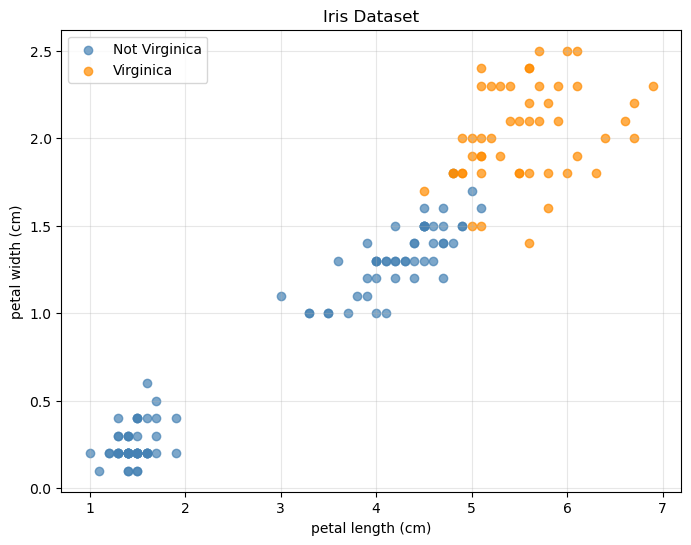

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# y=False：非鸢尾
plt.scatter(X[~y, 0], X[~y, 1], c="steelblue", label="Not Virginica", alpha=0.7)
# y=True：鸢尾花
plt.scatter(X[y, 0], X[y, 1], c="darkorange", label="Virginica", alpha=0.7)

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Iris Dataset")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

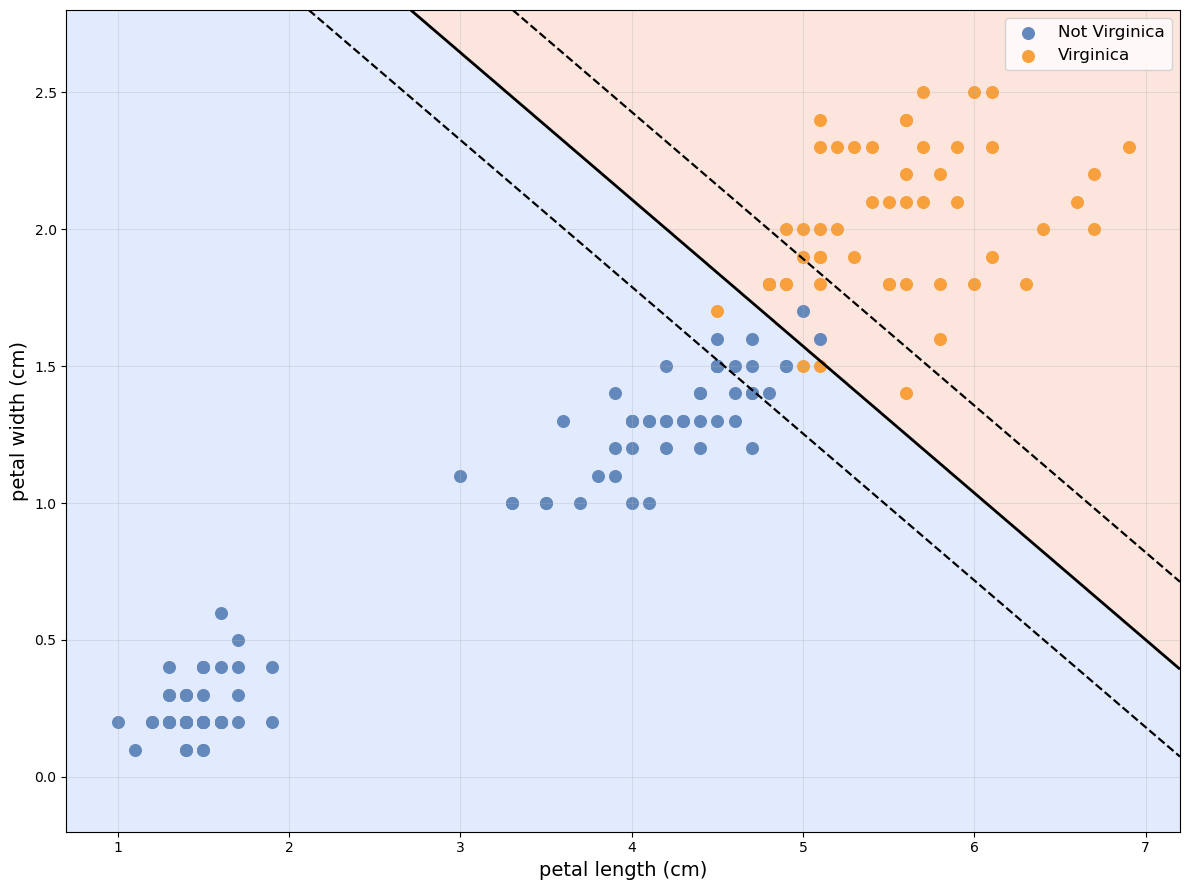

In [11]:
import numpy as np

svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=50, random_state=42))
svm_clf.fit(X, y)

svm = svm_clf[-1]
scaler = svm_clf[0]

# ===================== 创建网格，用于绘制等高线 =====================
x0_min, x0_max = X[:, 0].min()-0.3, X[:, 0].max()+0.3
x1_min, x1_max = X[:, 1].min()-0.3, X[:, 1].max()+0.3
xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 200), np.linspace(x1_min, x1_max, 200))
X_grid = np.c_[xx0.ravel(), xx1.ravel()]

# 标准化网格
df = svm_clf.decision_function(X_grid)
df = df.reshape(xx0.shape)

# ===================== 绘图 =====================
plt.figure(figsize=(12, 9))
# 绘制分类底色
plt.contourf(xx0, xx1, df>0, alpha=0.25, cmap="coolwarm")

# SVM核心：绘制决策边界 + 间隔margin（街道两条虚线）
# levels=[-1,0,+1]：-1和+1是间隔边界，0是分类决策线
cont = plt.contour(xx0, xx1, df,
                   colors="black",
                   levels=[-1, 0, 1],
                   linestyles=["--", "-", "--"],
                   linewidths=[1.6, 2, 1.6])

# 绘制样本点
mask_virginica = y
plt.scatter(X[~mask_virginica,0], X[~mask_virginica,1], c="#6388bb", s=70, label="Not Virginica")
plt.scatter(X[mask_virginica,0], X[mask_virginica,1], c="#f7a03c", s=70, label="Virginica")

plt.xlabel("petal length (cm)", fontsize=14)
plt.ylabel("petal width (cm)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

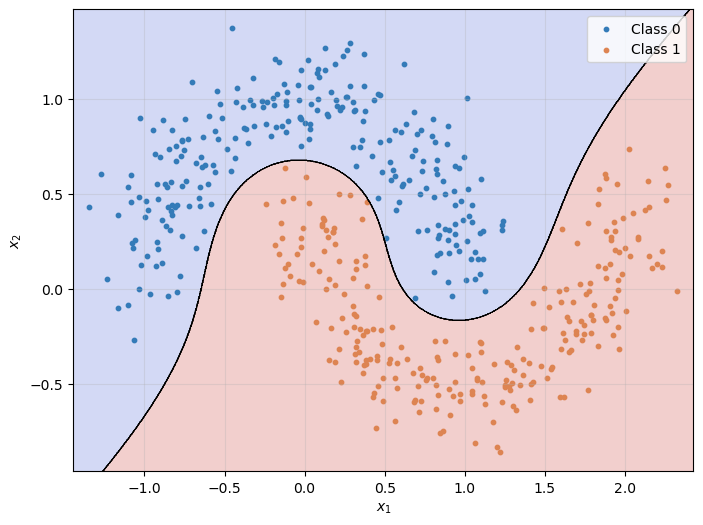

In [19]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=500,noise=0.15,random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3), # 多项式特征，最高3次项
    StandardScaler(),             # 标准化
    LinearSVC(C=10, max_iter=10_000, random_state=42)
)

polynomial_svm_clf.fit(X, y)

# ========== 绘制决策边界函数 ==========
def plot_decision_boundary(clf, X, y):
    plt.figure(figsize=(8,6))
    # 生成网格
    x0_min, x0_max = X[:,0].min()-0.1, X[:,0].max()+0.1
    x1_min, x1_max = X[:,1].min()-0.1, X[:,1].max()+0.1
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 1000),
                           np.linspace(x1_min, x1_max, 1000))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    
    # 预测网格所有点
    pred = clf.predict(grid)
    pred = pred.reshape(xx0.shape)

    # 填充分类区域
    plt.contourf(xx0, xx1, pred, alpha=0.25, cmap="coolwarm")
    # 画出分界线
    plt.contour(xx0, xx1, pred, colors="black", linewidths=0.5)

    # 绘制原始样本点
    plt.scatter(X[y==0,0], X[y==0,1], c="#347bb8", s=10, label="Class 0")
    plt.scatter(X[y==1,0], X[y==1,1], c="#dd8452", s=10, label="Class 1")
    
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary(polynomial_svm_clf, X, y)

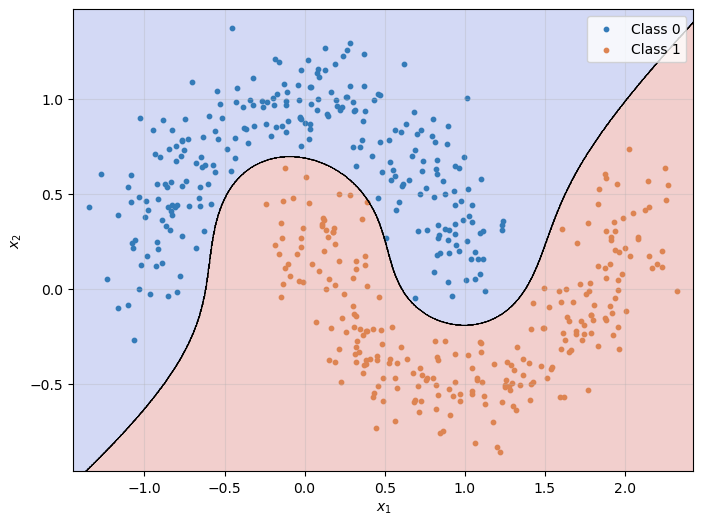

In [26]:
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(
    StandardScaler(),             # 标准化
    SVC(kernel='poly', degree=4, coef0=1, C=10)
)

poly_kernel_svm_clf.fit(X, y)

plot_decision_boundary(poly_kernel_svm_clf, X, y)

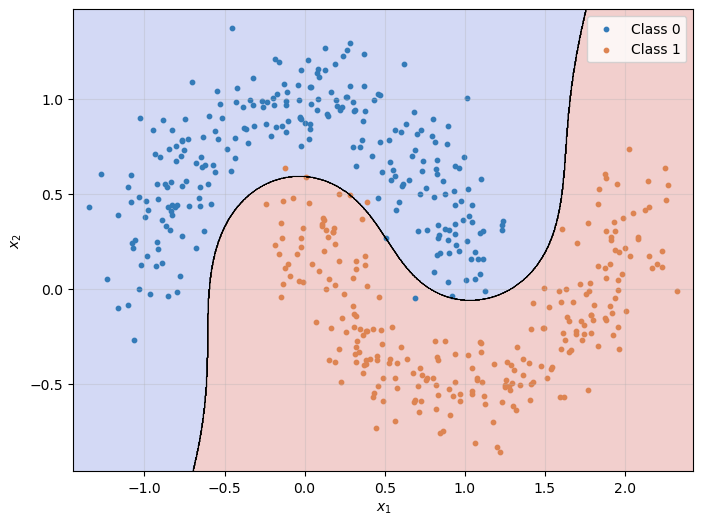

In [34]:
rbf_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC (kernel='rbf', gamma="scale", C=1)
)

rbf_kernel_svm_clf.fit(X, y)

plot_decision_boundary(rbf_kernel_svm_clf, X, y)